In [1]:
from mnist import MNIST
import numpy as np

mndata = MNIST(r'C:\Users\jitik\OneDrive\Desktop\Hands_on_ML_aurelion_geron\Chapter_10_geron\mnist')
images, labels = mndata.load_training()
test_images, test_labels = mndata.load_testing()

X_train = np.array(images)  / 255.0
y_train = np.array(labels)

X_test = np.array(test_images) / 255.0
y_test = np.array(test_labels)

print(X_train.shape)
print(y_train.shape)  

(60000, 784)
(60000,)


In [ ]:
input_dimension = 784
input_layer_dimension = input_dimension
output_layer_dimension = 10
num_classes = 10
layers = 3 # includes hidden + output layer
layer_dimension = (128, 64, output_layer_dimension)  # How many neurons in each layer excluding input layer which has 784 neurons
activ_1 = 'Relu'
activ_2 = 'Leaky Relu'
initialization_scheme = 'He'
Output_layer_activ = 'softmax'
loss_func = 'cross_entropy'

assert layers >= 1
assert layers == len(layer_dimension)

In [3]:
# weights_matrix = []
# bias_matrix = []

In [4]:
# comment this after train code is written

# hidden_layer_1_weight = np.random.randn(input_dimension, layer_dimension[0]) * np.sqrt(2. / input_dimension) # he initialization
# hidden_layer_1_bias = np.full(shape = (1,layer_dimension[0]),fill_value=0.11)
# print(hidden_layer_1_weight.shape)
# weights_matrix.append(hidden_layer_1_weight)
# bias_matrix.append(hidden_layer_1_bias)

# for i in range(len(layer_dimension) - 1):
#     layer_weights = np.random.randn(layer_dimension[i], layer_dimension[i+1]) * np.sqrt(2. / layer_dimension[i])
#     layer_bias = np.full(shape = (1,layer_dimension[i+1]),fill_value=0.11)
#     print(layer_weights.shape)
#     weights_matrix.append(layer_weights)
#     bias_matrix.append(layer_bias)

In [5]:
# def initialize_weights_and_biases_randomly(input_dimension : int, layer_dimension : tuple):
#     weights_matrix = []
#     bias_matrix = []
    
#     hidden_layer_1_weight = np.random.randn(input_dimension, layer_dimension[0]) * np.sqrt(2. / input_dimension) # he initialization
#     hidden_layer_1_bias = np.full(shape = (1,layer_dimension[0]),fill_value=0.11)
#     # print(hidden_layer_1_weight.shape)
#     weights_matrix.append(hidden_layer_1_weight)
#     bias_matrix.append(hidden_layer_1_bias)

#     for i in range(len(layer_dimension) - 1):
#         layer_weights = np.random.randn(layer_dimension[i], layer_dimension[i+1]) * np.sqrt(2. / layer_dimension[i])
#         layer_bias = np.full(shape = (1,layer_dimension[i+1]),fill_value=0.11)
#         # print(layer_weights.shape)
#         weights_matrix.append(layer_weights)
#         bias_matrix.append(layer_bias)

#     return weights_matrix,bias_matrix # Returns weights and bias matrix

In [6]:
def initialize_weights_and_biases_randomly(input_dimension: int, layer_dimension: tuple):
    weights_matrix = []
    bias_matrix = []

    in_dim = input_dimension
    for out_dim in layer_dimension:
        weight = np.random.randn(in_dim, out_dim) * np.sqrt(2.0 / in_dim)  # He initialization
        bias = np.full(shape = (1, out_dim),fill_value=0.1,dtype=np.float64)  # Standard: initialize biases to zeros
        # print(weight.shape)
        weights_matrix.append(weight)
        bias_matrix.append(bias)
        in_dim = out_dim  # Update for next layer

    return weights_matrix, bias_matrix


In [7]:
# shapes = [w.shape for w in weights_matrix]
# print("Weight matrix shapes (layer-wise):", shapes)

In [8]:
# shapes = [w.shape for w in bias_matrix]
# print("Bias matrix shapes (layer-wise):", shapes)

In [9]:
def softmax(z): # This is just a softmax with glorified numerical stability , simple softmax raised warnings 
    assert isinstance(z,np.ndarray)
    z_shift = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [10]:
def Relu(x):
    return np.maximum(0,x)

In [11]:
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

In [12]:
first_training_example = X_train[0].shape
first_training_example

(784,)

In [13]:
def forward_pass(X, weights_matrix, bias_matrix):
    activations = [X]  # store outputs of each layer
    A = X

    for i in range(len(weights_matrix)):

        Z = np.matmul(A, weights_matrix[i]) + bias_matrix[i]  # pre-activation
        # print(f"Layer {i} pre-activation Z stats: mean={Z.mean():.4f}, max={Z.max():.4f}, min={Z.min():.4f}")
        # print(f"Layer {i} post-activation A stats: mean={A.mean():.4f}, max={A.max():.4f}, min={A.min():.4f}")
        if i == len(weights_matrix) - 1:
            A = softmax(Z)  # output layer
        else:
            A = leaky_relu(Z)     # hidden layers
        activations.append(A)

    return activations  # list of all activations layer by layer

In [14]:
# input_layer_pre_activation = np.matmul(X_train,weights_matrix[0]) + bias_matrix[0]
# input_layer_activation = Relu(input_layer_pre_activation)
# input_layer_activation.shape

In [15]:
# layerwise_all_neurons_activations = forward_pass(X_train, weights_matrix, bias_matrix)
# output_layer_probs = layerwise_all_neurons_activations[-1]
# print("output shape:", output_layer_probs.shape)

In [16]:
# layerwise_all_neurons_activations[2].shape

In [17]:
# print(np.argmax(output_layer_probs[:10], axis=1)) # Predicted classes

In [18]:
# output_layer_probs[0]

In [19]:
# np.zeros((y_train.shape[0],10))

In [20]:
# np.arange(y_train.shape[0])

In [21]:
def one_hot_encode(y, num_classes):
    y = np.array(y).reshape(-1)  # Flatten in case it's shape (n,1)
    new_y = np.zeros((y.shape[0], num_classes), dtype=np.float64)
    new_y[np.arange(y.shape[0]), y] = 1.0
    return new_y


In [22]:
# def cross_entropy(y_hat: np.ndarray, y: np.ndarray) -> float:
#     epsilon = 1e-15  # Small value to avoid log(0)
#     y_hat_clipped = np.clip(y_hat, epsilon, 1 - epsilon)
#     return -np.sum(y * np.log(y_hat_clipped))

In [23]:
def cross_entropy(y_hat, y):
    eps = 1e-15
    y_hat_clipped = np.clip(y_hat, eps, 1-eps)
    sample_losses = -np.sum(y * np.log(y_hat_clipped), axis=1)
    return sample_losses

In [24]:
# Y_train_encoded = one_hot_encode(output_layer_probs,y_train,num_classes)

In [25]:
# cross_entropy(output_layer_probs,Y_train_encoded)

In [26]:
# np.heaviside() # usef for relu differentiation

In [27]:
def relu_diff(x):
    return np.heaviside(x,1)

In [28]:
def cross_entropy_diff(predictions,true_label):
    return (predictions - true_label) # y_should be one_hot encoded

In [29]:
# def output_layer_gradient_descent(all_layer_activations,weights_matrix,bias_matrix,Y_train_encoded,learning_rate = 0.001): 
#     # weight_gradients = []
#     # bias_gradients = []
#     # prev_layer_activations_gradients = []
#     layer = -1
#     # for _ in range(layers):
#     # layer = -1 - _ # iterating from back
#     # print(layer)
#     curr_layer_activations = all_layer_activations[layer]
#     prev_layer_activations = all_layer_activations[layer-1]
    
#     # Assume softmax + cross entropy: dC/dz = y_hat - y_true
#     delta = cross_entropy_diff(curr_layer_activations,Y_train_encoded)

#     # print(delta.shape)
#     # print(prev_layer_activations.shape)
#     weight_grad = prev_layer_activations.T @ delta
#     bias_grad = np.sum(delta, axis=0, keepdims=True)
#     # print(bias_grad.shape)
#     # print(weights_matrix[layer].shape)
#     prev_layer_activations_grad = delta @ weights_matrix[layer].T 
#     # weight_gradients.append(weight_grad)
#     # bias_gradients.append(bias_grad)              
#     # prev_layer_activations_gradients.append(prev_layer_activations_grad)
#     weights_matrix[layer] -= learning_rate * weight_grad
#     bias_matrix[layer] -= learning_rate * bias_grad # Gradient Descent Step in place

#     return prev_layer_activations_grad # dc / d aL-1

In [30]:
# weights_matrix[-1][0]

In [31]:
# learning_rate = 0.01
# prev_layer_activations_gradients = output_layer_gradient_descent(layerwise_all_neurons_activations,weights_matrix,bias_matrix,Y_train_encoded,learning_rate)

In [32]:
# prev_layer_activations_gradients.shape

In [33]:
# prev_layer_activations_gradients[0].shape

In [34]:
# for layer in range(1,layers):
#     layer = -1 - layer
#     print(layer)

In [35]:
# weights_matrix[-2].shape

In [36]:
# def hidden_layer_gradient_descent(all_layer_activations,weights_matrix,bias_matrix,prev_layer_activations_gradients,learning_rate = 0.001):
#     post_layer_gradient = prev_layer_activations_gradients # This is dC/dA_L-1 (i.e., gradient from output layer)

#     for layer in range(1,layers): # Starting from one to skip output layer
        
#         layer = -1 - layer
#         curr_layer_activations = all_layer_activations[layer]
#         prev_layer_activations = all_layer_activations[layer - 1]
#         # print(f"Layer {layer}")
#         # print("post_layer_gradient:", post_layer_gradient.shape)
#         # print("weights_matrix[layer+1]:", weights_matrix[layer+1].shape)
#         # print("ReLu_diff:", relu_diff(curr_layer_activations).shape)
#         # print("prev_layer_activations:", prev_layer_activations.shape)

#         delta = (post_layer_gradient) * leaky_relu_derivative(curr_layer_activations) # dc / da l - 1(previous Gradient) *  d a l -1 / d z l - 1 (relu-diff)
#         weight_grad = prev_layer_activations.T @ delta
#         bias_grad = np.sum(delta, axis=0, keepdims=True)
#         prev_layer_activations_grad = delta @ weights_matrix[layer].T 

#         weights_matrix[layer] -= learning_rate * weight_grad
#         bias_matrix[layer] -= learning_rate * bias_grad # Gradient Descent Step
#         post_layer_gradient = prev_layer_activations_grad # To loop gradients backprogogate on previous layer

In [37]:
# hidden_layer_gradient_descent(layerwise_all_neurons_activations,weights_matrix,bias_matrix,prev_layer_activations_gradients,learning_rate)

In [38]:
# Used for adjusting weights and biases by propogating error backwards
# def backpropagate(layerwise_all_neurons_activations,weights_matrix,bias_matrix,Y_train_encoded,learning_rate = 0.11):
#     hidden_layer_before_output_layer_activation_gradient = output_layer_gradient_descent(layerwise_all_neurons_activations,weights_matrix,bias_matrix,Y_train_encoded,learning_rate)
#     hidden_layer_gradient_descent(layerwise_all_neurons_activations,weights_matrix,bias_matrix,hidden_layer_before_output_layer_activation_gradient,learning_rate)
    

In [39]:
def backpropagate(activations, weights_matrix, bias_matrix, Y_train_encoded, learning_rate):
    hidden_grad = output_layer_gradient_descent(
        activations, weights_matrix, bias_matrix, Y_train_encoded, learning_rate)
    hidden_layer_gradient_descent(
        activations, weights_matrix, bias_matrix, hidden_grad, learning_rate)

def hidden_layer_gradient_descent(activations, weights_matrix, bias_matrix, post_layer_gradient, learning_rate):
    num_layers = len(weights_matrix)
    for i in range(2, num_layers + 1):
        layer = -i  # counts -2, -3, ... for hidden layers
        curr_activ = activations[layer]
        prev_activ = activations[layer - 1]
        delta = post_layer_gradient * leaky_relu_derivative(curr_activ)
        # After computing gradients, before weight updates:
        weight_grad = prev_activ.T @ delta
        bias_grad = np.sum(delta, axis=0, keepdims=True)

        weight_grad = np.clip(weight_grad, -1.0, 1.0)
        bias_grad = np.clip(bias_grad, -1.0, 1.0)

        post_layer_gradient = delta @ weights_matrix[layer].T
        weights_matrix[layer] -= learning_rate * weight_grad
        bias_matrix[layer] -= learning_rate * bias_grad

def output_layer_gradient_descent(activations, weights_matrix, bias_matrix, Y_train_encoded, learning_rate):
    layer = -1
    out_activ = activations[layer]
    prev_activ = activations[layer - 1]
    delta = cross_entropy_diff(out_activ, Y_train_encoded)
    weight_grad = prev_activ.T @ delta
    bias_grad = np.sum(delta, axis=0, keepdims=True)

    weight_grad = np.clip(weight_grad, -1.0, 1.0)
    bias_grad = np.clip(bias_grad, -1.0, 1.0)

    prev_layer_grad = delta @ weights_matrix[layer].T
    weights_matrix[layer] -= learning_rate * weight_grad
    bias_matrix[layer] -= learning_rate * bias_grad
    return prev_layer_grad


In [40]:
# weights_matrix, bias_matrix = initialize_weights_and_biases_randomly(input_dimension, layer_dimension)

In [41]:
# for epoch in range(1000):  # Try just 2 epochs to start
#     activations = forward_pass(X_train[:2], weights_matrix, bias_matrix)

In [42]:
# print("Layer 2 weights:", weights_matrix[2])
# print("Layer 2 bias:", bias_matrix[2])

In [43]:
def train_neural_network(X, Y, X_t, Y_t, input_dimension: int, layer_dimension: tuple, num_classes: int = 10, epochs: int = 1000, learning_rate: float = 0.001, batch_size: int = 64) -> tuple:
    assert X.shape[0] == Y.shape[0]
    assert X_t.shape[0] == Y_t.shape[0]
    weights_matrix, bias_matrix = initialize_weights_and_biases_randomly(input_dimension, layer_dimension)
    num_samples = X.shape[0]
    average_loss_history = []
    loss_history = []
    accuracy_history = []

    for epoch in range(epochs):
        # Shuffle the data
        indices = np.arange(num_samples)
        np.random.shuffle(indices)
        X = X[indices]
        Y = Y[indices]

        epoch_loss = 0
        num_batches = 0

        for start in range(0, num_samples, batch_size):
            end = start + batch_size
            X_batch = X[start:end]
            Y_batch = Y[start:end]

            activations = forward_pass(X_batch, weights_matrix, bias_matrix)
            output_probs = activations[-1]
            Y_encoded = one_hot_encode(Y_batch, num_classes)
            loss = cross_entropy(output_probs, Y_encoded)
            epoch_loss += np.sum(loss) 
            num_batches += 1

            backpropagate(activations, weights_matrix, bias_matrix, Y_encoded, learning_rate)

        # average_loss = epoch_loss / num_batches

        # Eval on test set 
        test_activations = forward_pass(X_t, weights_matrix, bias_matrix)
        test_output_probs = test_activations[-1]  # shape (num_test_samples, num_classes)
        test_pred_labels = np.argmax(test_output_probs, axis=1)

        test_accuracy = np.mean(test_pred_labels == Y_t)
        average_epoch_loss = epoch_loss/num_batches

        print(f"Epoch {epoch}: average_loss = {average_epoch_loss:.4f},entropy_loss = {epoch_loss :.4f}, test accuracy = {test_accuracy*100:.2f}%")

        average_loss_history.append(average_epoch_loss)
        accuracy_history.append(test_accuracy)
        loss_history.append(epoch_loss)

    return weights_matrix, bias_matrix, np.array(average_loss_history), np.array(accuracy_history) * 100, np.array(loss_history)

In [44]:
epochs = 100
weights_matrix_final, bias_matrix_final, average_loss_history, accuracy_history,loss_history = train_neural_network(X_train,y_train,X_test,y_test,input_layer_dimension,layer_dimension,10,epochs,0.01,batch_size=32)

Epoch 0: average_loss = 7.8774,entropy_loss = 14770.1758, test accuracy = 95.91%
Epoch 1: average_loss = 3.8337,entropy_loss = 7188.1761, test accuracy = 96.72%
Epoch 2: average_loss = 2.9571,entropy_loss = 5544.6152, test accuracy = 96.51%
Epoch 3: average_loss = 2.5255,entropy_loss = 4735.4004, test accuracy = 97.36%
Epoch 4: average_loss = 2.1218,entropy_loss = 3978.4153, test accuracy = 97.56%
Epoch 5: average_loss = 1.6737,entropy_loss = 3138.1722, test accuracy = 97.13%
Epoch 6: average_loss = 1.4435,entropy_loss = 2706.5539, test accuracy = 97.23%
Epoch 7: average_loss = 1.2115,entropy_loss = 2271.5967, test accuracy = 97.70%
Epoch 8: average_loss = 0.9936,entropy_loss = 1862.9937, test accuracy = 97.73%
Epoch 9: average_loss = 0.7258,entropy_loss = 1360.9318, test accuracy = 97.46%
Epoch 10: average_loss = 0.6289,entropy_loss = 1179.1250, test accuracy = 97.71%
Epoch 11: average_loss = 0.5506,entropy_loss = 1032.4257, test accuracy = 97.68%
Epoch 12: average_loss = 0.5023,entro

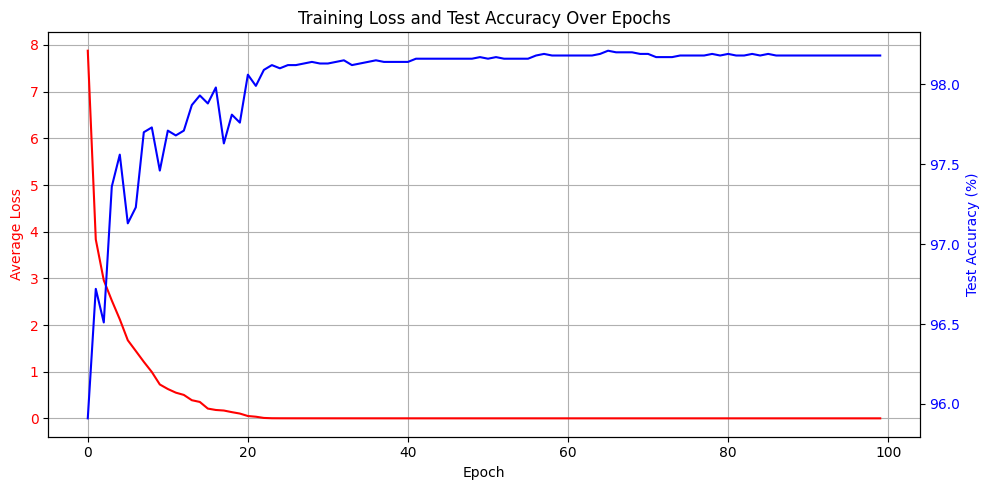

In [55]:
import matplotlib.pyplot as plt
epoch_range = list(range(epochs))
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Average Loss', color=color)
ax1.plot(epoch_range, average_loss_history, color=color, label='Average Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()
color = 'blue'
ax2.set_ylabel('Test Accuracy (%)', color=color)
ax2.plot(epoch_range, accuracy_history, color=color, label='Test Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Training Loss and Test Accuracy Over Epochs')
fig.tight_layout()
plt.show()


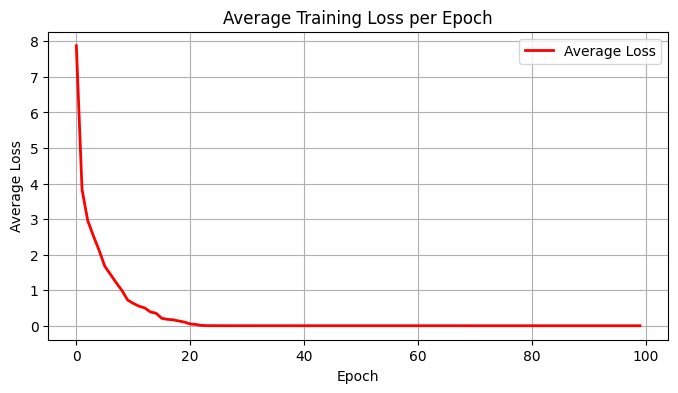

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(average_loss_history, color='red', linewidth=2, label='Average Loss')
plt.title('Average Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True)
plt.legend()
plt.show()


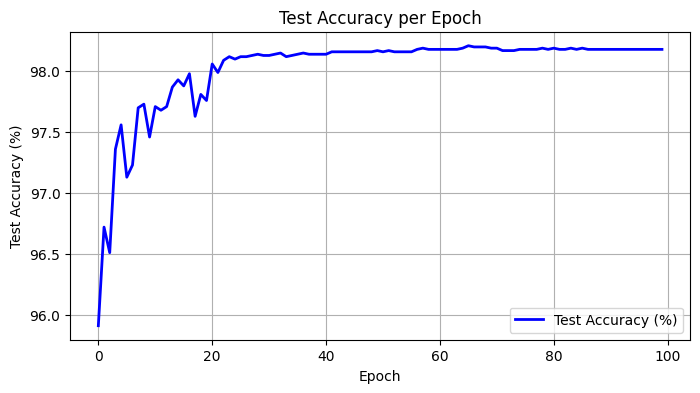

In [51]:
plt.figure(figsize=(8, 4))
plt.plot(accuracy_history, color='blue', linewidth=2, label='Test Accuracy (%)')
plt.title('Test Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.grid(True)
plt.legend()
plt.show()


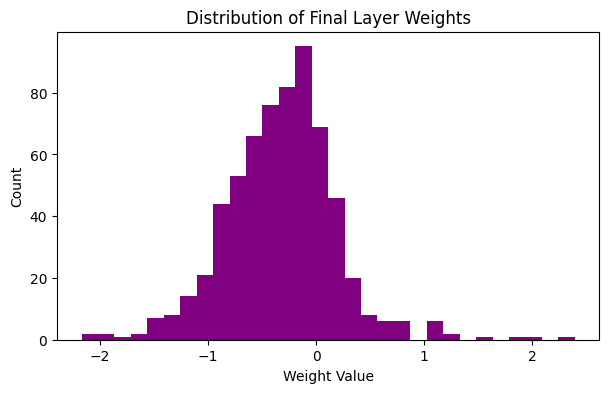

In [53]:
final_layer_weights = weights_matrix_final[-1].flatten()
plt.figure(figsize=(7,4))
plt.hist(final_layer_weights, bins=30, color='purple')
plt.title('Distribution of Final Layer Weights')
plt.xlabel('Weight Value')
plt.ylabel('Count')
plt.show()


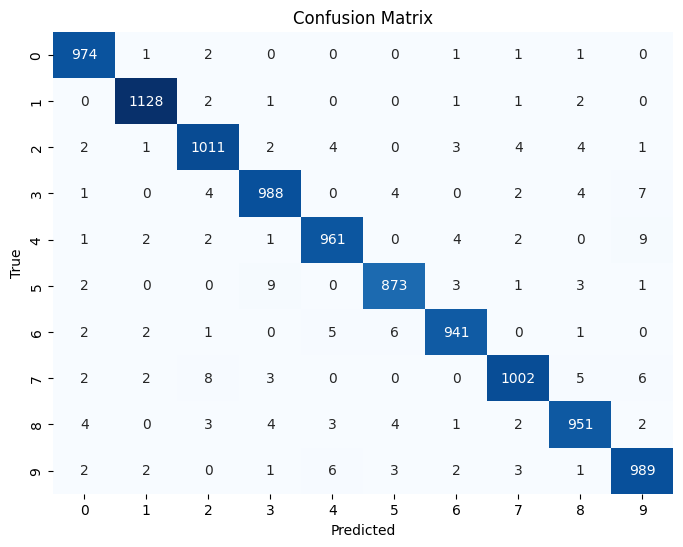

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

test_pred_labels = np.argmax(forward_pass(X_test, weights_matrix_final, bias_matrix_final)[-1], axis=1)
cm = confusion_matrix(y_test, test_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
accuracy_history[:100]

array([81.66, 87.1 , 74.64, 88.53, 88.39, 86.68, 81.25, 85.63, 57.82,
       84.41, 84.73, 76.77, 78.93, 82.52, 84.19, 81.57, 82.12, 83.82,
       86.5 , 83.73, 84.98, 80.4 , 87.79, 86.32, 85.33, 87.45, 87.1 ,
       86.76, 88.2 , 86.81, 89.83, 90.97, 88.1 , 87.42, 88.81, 85.07,
       89.  , 90.08, 88.9 , 89.54, 90.31, 89.82, 86.76, 88.22, 91.36,
       91.37, 89.52, 89.66, 90.36, 90.37, 91.42, 91.03, 91.32, 91.3 ,
       91.66, 91.67, 91.17, 90.1 , 91.79, 89.3 , 90.43, 89.55, 89.94,
       89.08, 90.31, 89.04, 89.86, 89.98, 90.39, 90.08, 89.81, 91.79,
       90.4 , 90.42, 90.86, 91.06, 91.41, 90.1 , 91.29, 91.87, 90.47,
       90.22, 91.41, 91.83, 91.41, 92.17, 91.78, 91.77, 91.73, 88.78,
       91.43, 91.42, 92.17, 91.96, 92.41, 92.1 , 91.74, 92.43, 92.1 ,
       91.98])

ValueError: x and y must have same first dimension, but have shapes (100,) and (1000000,)

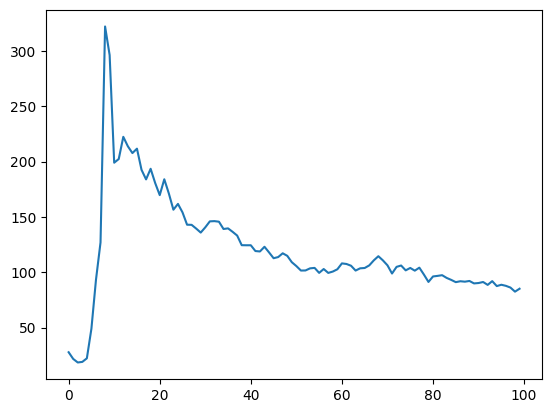

In [ ]:
import matplotlib.pyplot as plt

plt.plot(epochs,loss_history, label='Train Loss')
plt.plot(epochs,accuracy_history, label='Test Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.title('Training Loss & Test Accuracy')
plt.show()

In [ ]:
# activations = forward_pass(X_train[:2], weights_matrix, bias_matrix)
# for i, A in enumerate(activations):
#     print(f"Layer {i} activation stats: mean={A.mean()}, max={A.max()}, min={A.min()}")

In [ ]:
# y_hat = np.array([[0.9, 0.1]])      # prediction (batch size 1)
# y = np.array([[1, 0]])              # true label (class 0)

# print(cross_entropy(y_hat, y))      # should give small but positive value, e.g. ~0.1


In [ ]:
# for epoch in range(4):  # Try just 2 epochs to start
#     activations = forward_pass(X_train[:2], weights_matrix, bias_matrix)

In [ ]:
# cross_entropy(output_layer_probs,Y_train_encoded)

In [ ]:
# layer_dimension

In [ ]:
# X_train.shape[0]

In [ ]:
# y_train.shape[0]

In [ ]:
# def forward_pass(X, weights_matrix, bias_matrix):
#     activations = [X]  # store outputs of each layer
#     A = X

#     for i in range(len(weights_matrix)):
#         Z = np.matmul(A, weights_matrix[i]) + bias_matrix[i]  # pre-activation
#         if i == len(weights_matrix) - 1:
#             A = softmax(Z)  # output layer
#         else:
#             A = Relu(Z)     # hidden layers
#         activations.append(A)

#     return activations  # list of all activations layer by layer